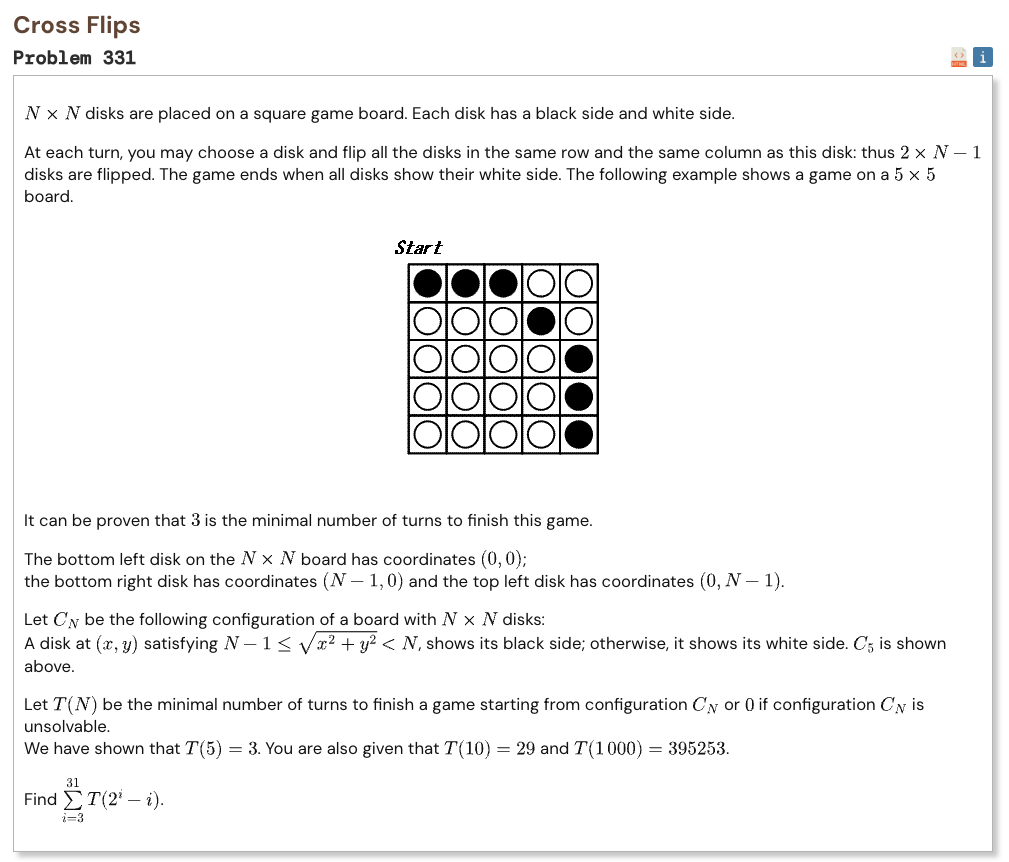

## Initial approach

* model every disk as a binary value
* model every possible move as a binary variable
* for even board sizes, the solution is unique
* use row parity and column parity to build that solution without testing move orders
* the black disks form one interval in each row
* count row parities and black interval sizes with integer square roots
* use the known odd-board rule from the problem statement
* sum the requested board sizes and print the result

```python

import math

def T(n):
    if n == 5:
        return 3

    if n % 2 == 1:
        return 0

    n2 = n * n
    row_parity = [0] * n
    y_inner = [0] * n
    y_outer = [0] * n

    odd_rows = 0
    black_total = 0

    for x in range(n):
        x2 = x * x
        outer = math.isqrt(n2 - 1 - x2)

        if x == n - 1:
            inner = -1
        else:
            value = n2 - 2 * n - x2
            inner = math.isqrt(value) if value >= 0 else -1

        y_outer[x] = outer
        y_inner[x] = inner

        length = outer - inner
        black_total += length

        parity = length & 1
        row_parity[x] = parity
        odd_rows += parity

    prefix = [0] * (n + 1)

    for i in range(n):
        prefix[i + 1] = prefix[i] + row_parity[i]

    black_with_different_parity = 0

    for x in range(n):
        left = y_inner[x] + 1
        right = y_outer[x]

        if left < 0:
            left = 0

        if left > right:
            continue

        ones = prefix[right + 1] - prefix[left]
        length = right - left + 1

        if row_parity[x] == 0:
            black_with_different_parity += ones
        else:
            black_with_different_parity += length - ones

    return 2 * odd_rows * (n - odd_rows) + black_total - 2 * black_with_different_parity

def solve():
    total = 0

    for i in range(3, 32):
        n = 2 ** i - i
        total += T(n)

    return total

assert T(5) == 3
assert T(10) == 29
assert T(1000) == 395253

result = solve()
print("Result:", result)
```

Note: it takes too much time to run. needs to be optimized.